# Анализ и подготовка медицинского датасета

Этот ноутбук содержит код для анализа и очистки медицинского датасета с визуализациями на каждом этапе.


In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
from datetime import datetime
import re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Библиотеки успешно импортированы!")


Библиотеки успешно импортированы!


## 1. Загрузка данных


In [2]:
# Загрузка данных
input_file = 'healthcare_dataset.csv'
df = pd.read_csv(input_file)

print(f"Размер датасета: {df.shape}")
print(f"\nПервые 5 строк:")
df.head()


Размер датасета: (55500, 15)

Первые 5 строк:


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## 2. Анализ исходных данных


In [3]:
# Базовая информация о датасете
print("="*60)
print("БАЗОВАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ")
print("="*60)
print(f"\nРазмер: {df.shape[0]} строк, {df.shape[1]} колонок")
print(f"\nКолонки:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

print(f"\nТипы данных:")
print(df.dtypes)

print(f"\nОбщая информация:")
df.info()


БАЗОВАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ

Размер: 55500 строк, 15 колонок

Колонки:
1. Name
2. Age
3. Gender
4. Blood Type
5. Medical Condition
6. Date of Admission
7. Doctor
8. Hospital
9. Insurance Provider
10. Billing Amount
11. Room Number
12. Admission Type
13. Discharge Date
14. Medication
15. Test Results

Типы данных:
Name                   object
Age                     int64
Gender                 object
Blood Type             object
Medical Condition      object
Date of Admission      object
Doctor                 object
Hospital               object
Insurance Provider     object
Billing Amount        float64
Room Number             int64
Admission Type         object
Discharge Date         object
Medication             object
Test Results           object
dtype: object

Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -

✓ Пропусков не обнаружено!


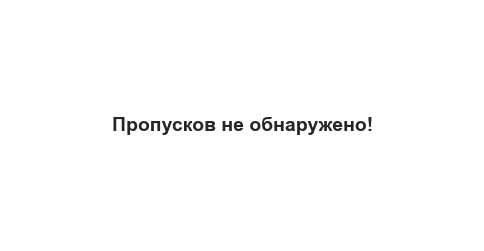

In [4]:
# Визуализация пропусков в данных
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Пропусков': missing,
    'Процент': missing_pct
}).sort_values('Пропусков', ascending=False)

if missing_df['Пропусков'].sum() > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    missing_df[missing_df['Пропусков'] > 0].plot(kind='barh', y='Пропусков', ax=ax, color='coral')
    ax.set_title('Пропуски в данных', fontsize=14, fontweight='bold')
    ax.set_xlabel('Количество пропусков')
    plt.tight_layout()
    plt.show()
    print(missing_df[missing_df['Пропусков'] > 0])
else:
    print("✓ Пропусков не обнаружено!")
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.text(0.5, 0.5, 'Пропусков не обнаружено!', 
            ha='center', va='center', fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.show()


АНАЛИЗ ПРОБЛЕМ С ИМЕНАМИ

Имен с неправильным регистром: 55467
Имен с префиксами: 2108

Примеры имен с неправильным регистром:
['Bobby JacksOn', 'LesLie TErRy', 'DaNnY sMitH', 'andrEw waTtS', 'adrIENNE bEll', 'EMILY JOHNSOn', 'edwArD EDWaRDs', 'CHrisTInA MARtinez', 'JASmINe aGuIlaR', 'ChRISTopher BerG']

Примеры имен с префиксами:
['andrEw waTtS', 'adrIENNE bEll', 'MS. nAtalIE gAMble', 'mr. KenNEth MoORE', 'NicOlE RodriGUEz', 'CasSAndrA Robinson', 'Mr. eRiC Lane', 'AdriaN BuckLEY', 'MR. TYler TAYLOR Phd', 'DR. LaUreN ClaRk DDs']


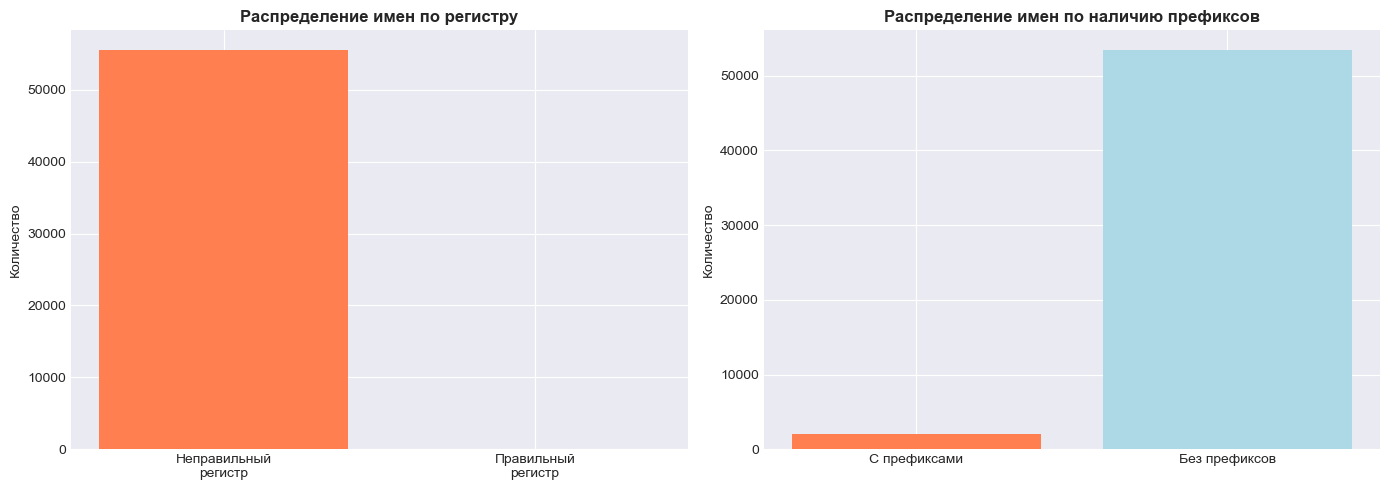

In [5]:
# Анализ проблем с именами
print("="*60)
print("АНАЛИЗ ПРОБЛЕМ С ИМЕНАМИ")
print("="*60)

# Имена с неправильным регистром
names_with_wrong_case = df['Name'].apply(lambda x: x != x.title() and x.lower() != x.upper())
wrong_case_count = names_with_wrong_case.sum()

# Имена с префиксами
prefixes = ['Mr.', 'Mrs.', 'MS.', 'Dr.', 'mr.', 'mrs.', 'ms.', 'dr.', 'MR.', 'MRS.', 'MS.', 'DR.']
names_with_prefix = df['Name'].str.contains('|'.join(prefixes), na=False)
prefix_count = names_with_prefix.sum()

print(f"\nИмен с неправильным регистром: {wrong_case_count}")
print(f"Имен с префиксами: {prefix_count}")

# Примеры проблемных имен
if wrong_case_count > 0:
    print(f"\nПримеры имен с неправильным регистром:")
    print(df[names_with_wrong_case]['Name'].head(10).tolist())

if prefix_count > 0:
    print(f"\nПримеры имен с префиксами:")
    print(df[names_with_prefix]['Name'].head(10).tolist())

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График проблем с регистром
ax1.bar(['Неправильный\nрегистр', 'Правильный\nрегистр'], 
        [wrong_case_count, len(df) - wrong_case_count], 
        color=['coral', 'lightblue'])
ax1.set_title('Распределение имен по регистру', fontsize=12, fontweight='bold')
ax1.set_ylabel('Количество')

# График префиксов
ax2.bar(['С префиксами', 'Без префиксов'], 
        [prefix_count, len(df) - prefix_count], 
        color=['coral', 'lightblue'])
ax2.set_title('Распределение имен по наличию префиксов', fontsize=12, fontweight='bold')
ax2.set_ylabel('Количество')

plt.tight_layout()
plt.show()


АНАЛИЗ BILLING AMOUNT
Отрицательных сумм: 108
Очень низких сумм (< 100): 130
Очень высоких сумм (> 100000): 0
Диапазон: -2008.49 - 52764.28
Среднее: 25539.32
Медиана: 25538.07


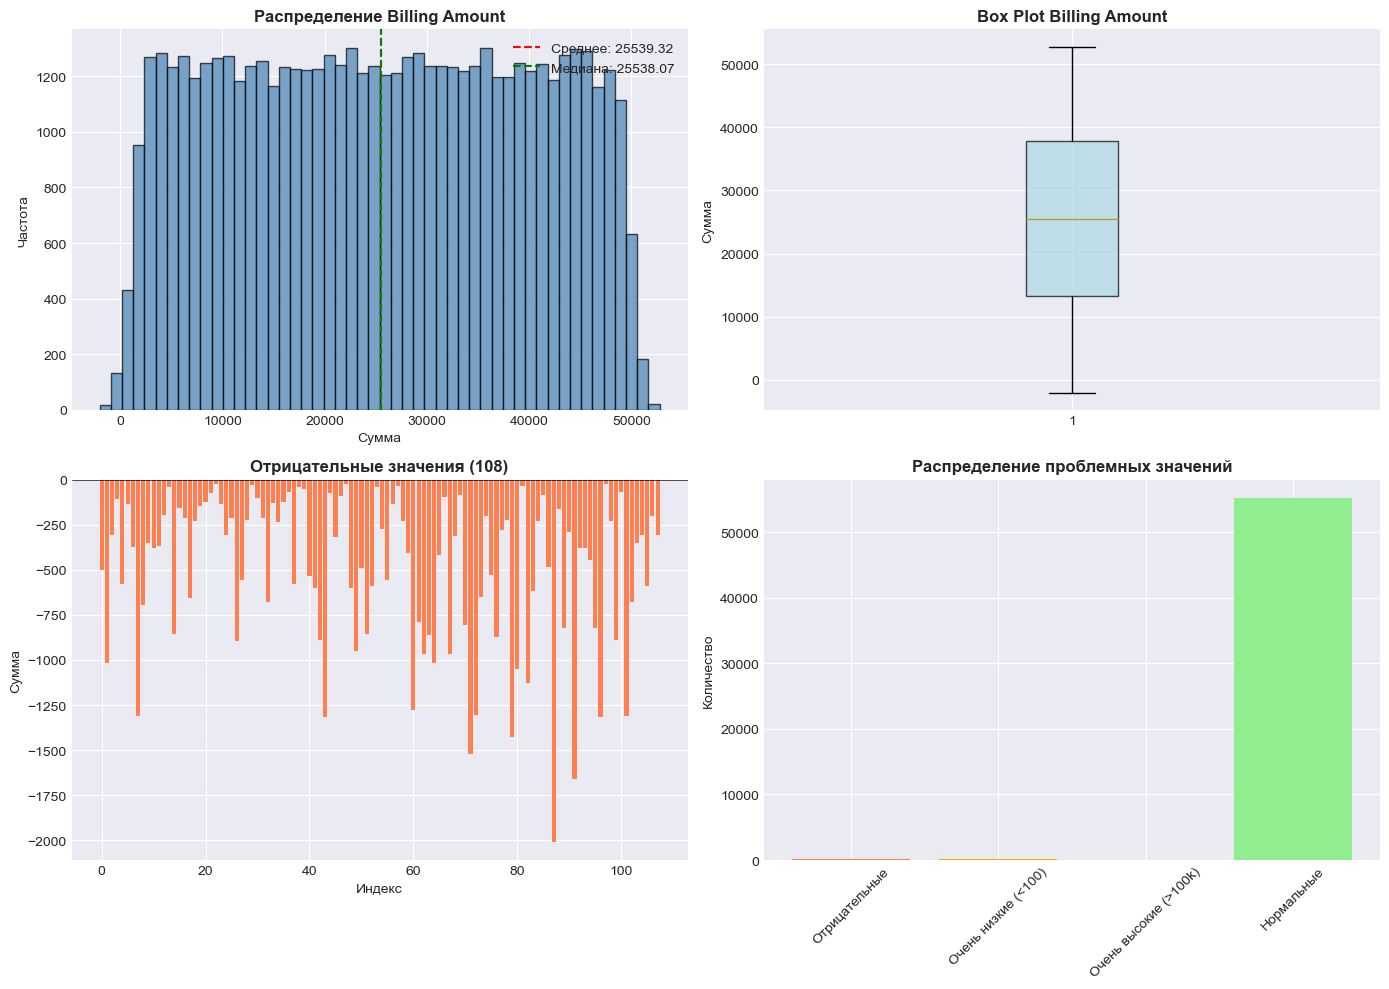

In [6]:
# Анализ Billing Amount
print("="*60)
print("АНАЛИЗ BILLING AMOUNT")
print("="*60)

negative_count = (df['Billing Amount'] < 0).sum()
very_low_count = (df['Billing Amount'] < 100).sum()
very_high_count = (df['Billing Amount'] > 100000).sum()

print(f"Отрицательных сумм: {negative_count}")
print(f"Очень низких сумм (< 100): {very_low_count}")
print(f"Очень высоких сумм (> 100000): {very_high_count}")
print(f"Диапазон: {df['Billing Amount'].min():.2f} - {df['Billing Amount'].max():.2f}")
print(f"Среднее: {df['Billing Amount'].mean():.2f}")
print(f"Медиана: {df['Billing Amount'].median():.2f}")

# Визуализация распределения Billing Amount
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Гистограмма
axes[0, 0].hist(df['Billing Amount'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['Billing Amount'].mean(), color='red', linestyle='--', 
                   label=f'Среднее: {df["Billing Amount"].mean():.2f}')
axes[0, 0].axvline(df['Billing Amount'].median(), color='green', linestyle='--', 
                   label=f'Медиана: {df["Billing Amount"].median():.2f}')
axes[0, 0].set_title('Распределение Billing Amount', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Сумма')
axes[0, 0].set_ylabel('Частота')
axes[0, 0].legend()

# Box plot
axes[0, 1].boxplot(df['Billing Amount'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[0, 1].set_title('Box Plot Billing Amount', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Сумма')

# Отрицательные значения
if negative_count > 0:
    negative_values = df[df['Billing Amount'] < 0]['Billing Amount']
    axes[1, 0].bar(range(len(negative_values)), negative_values.values, color='coral')
    axes[1, 0].set_title(f'Отрицательные значения ({negative_count})', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Индекс')
    axes[1, 0].set_ylabel('Сумма')
    axes[1, 0].axhline(0, color='black', linestyle='-', linewidth=0.5)
else:
    axes[1, 0].text(0.5, 0.5, 'Отрицательных значений нет', 
                    ha='center', va='center', fontsize=12)
    axes[1, 0].axis('off')

# Статистика по проблемным значениям
problem_data = {
    'Отрицательные': negative_count,
    'Очень низкие (<100)': very_low_count,
    'Очень высокие (>100k)': very_high_count,
    'Нормальные': len(df) - negative_count - very_low_count - very_high_count
}
axes[1, 1].bar(problem_data.keys(), problem_data.values(), color=['coral', 'orange', 'gold', 'lightgreen'])
axes[1, 1].set_title('Распределение проблемных значений', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Количество')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


АНАЛИЗ КАТЕГОРИАЛЬНЫХ ДАННЫХ


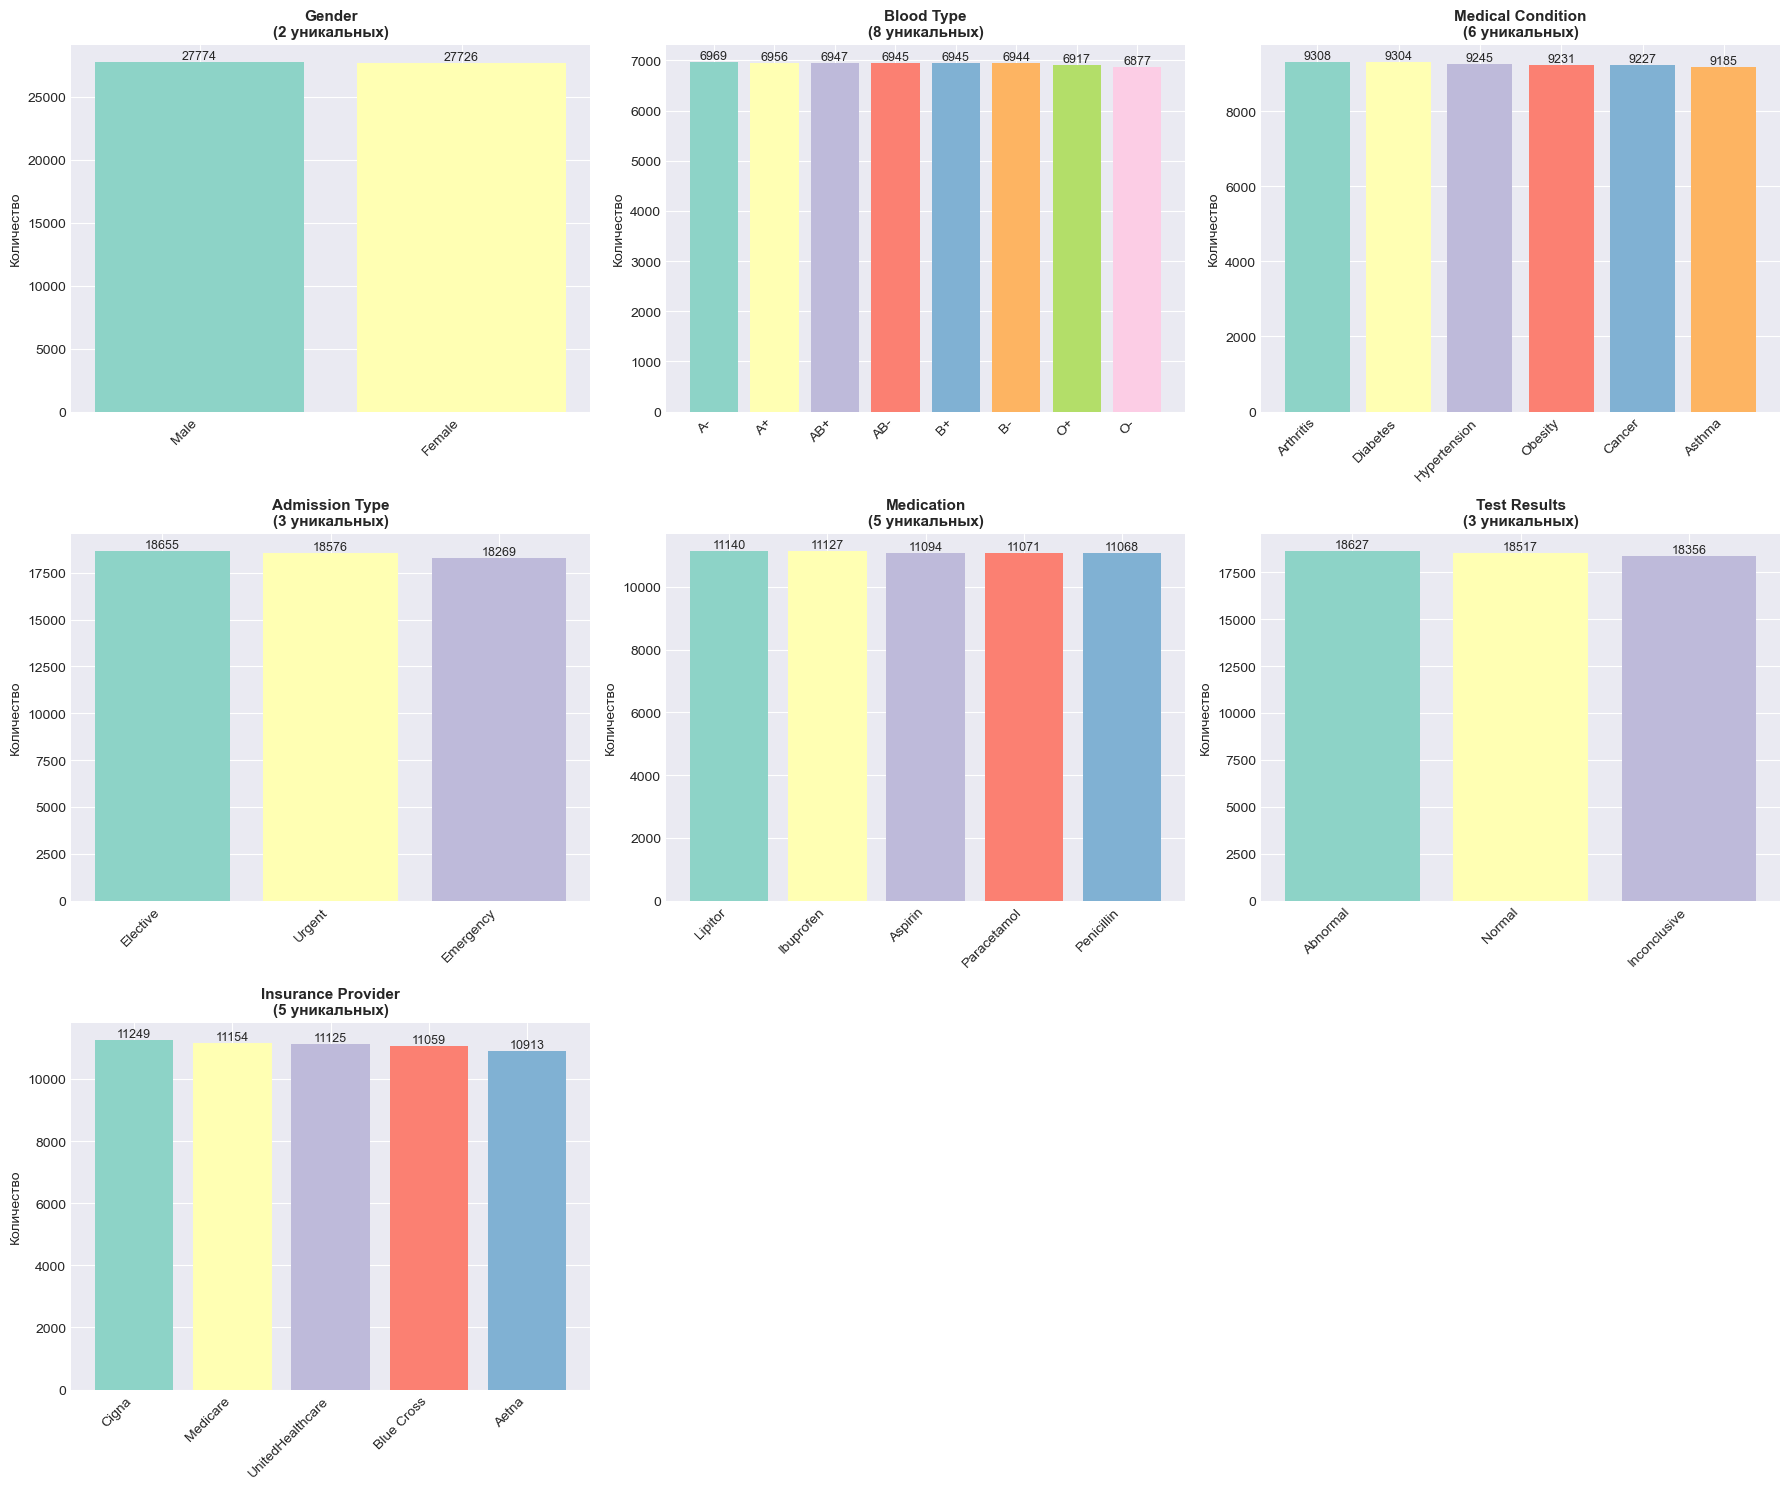


Gender:
  Уникальных значений: 2
  Топ-5 значений:
Gender
Male      27774
Female    27726
Name: count, dtype: int64

Blood Type:
  Уникальных значений: 8
  Топ-5 значений:
Blood Type
A-     6969
A+     6956
AB+    6947
AB-    6945
B+     6945
Name: count, dtype: int64

Medical Condition:
  Уникальных значений: 6
  Топ-5 значений:
Medical Condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Name: count, dtype: int64

Admission Type:
  Уникальных значений: 3
  Топ-5 значений:
Admission Type
Elective     18655
Urgent       18576
Emergency    18269
Name: count, dtype: int64

Medication:
  Уникальных значений: 5
  Топ-5 значений:
Medication
Lipitor        11140
Ibuprofen      11127
Aspirin        11094
Paracetamol    11071
Penicillin     11068
Name: count, dtype: int64

Test Results:
  Уникальных значений: 3
  Топ-5 значений:
Test Results
Abnormal        18627
Normal          18517
Inconclusive    18356
Name: count, dtype: int64

In [7]:
# Анализ категориальных данных
print("="*60)
print("АНАЛИЗ КАТЕГОРИАЛЬНЫХ ДАННЫХ")
print("="*60)

categorical_cols = ['Gender', 'Blood Type', 'Medical Condition', 'Admission Type', 
                   'Medication', 'Test Results', 'Insurance Provider']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    value_counts = df[col].value_counts()
    axes[idx].bar(range(len(value_counts)), value_counts.values, color=plt.cm.Set3(range(len(value_counts))))
    axes[idx].set_title(f'{col}\n({df[col].nunique()} уникальных)', fontsize=11, fontweight='bold')
    axes[idx].set_xticks(range(len(value_counts)))
    axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
    axes[idx].set_ylabel('Количество')
    
    # Добавляем значения на столбцы
    for i, v in enumerate(value_counts.values):
        axes[idx].text(i, v, str(v), ha='center', va='bottom', fontsize=9)

# Скрываем лишние подграфики
for idx in range(len(categorical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Статистика
for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Уникальных значений: {df[col].nunique()}")
    print(f"  Топ-5 значений:")
    print(df[col].value_counts().head())


АНАЛИЗ ЧИСЛОВЫХ ДАННЫХ


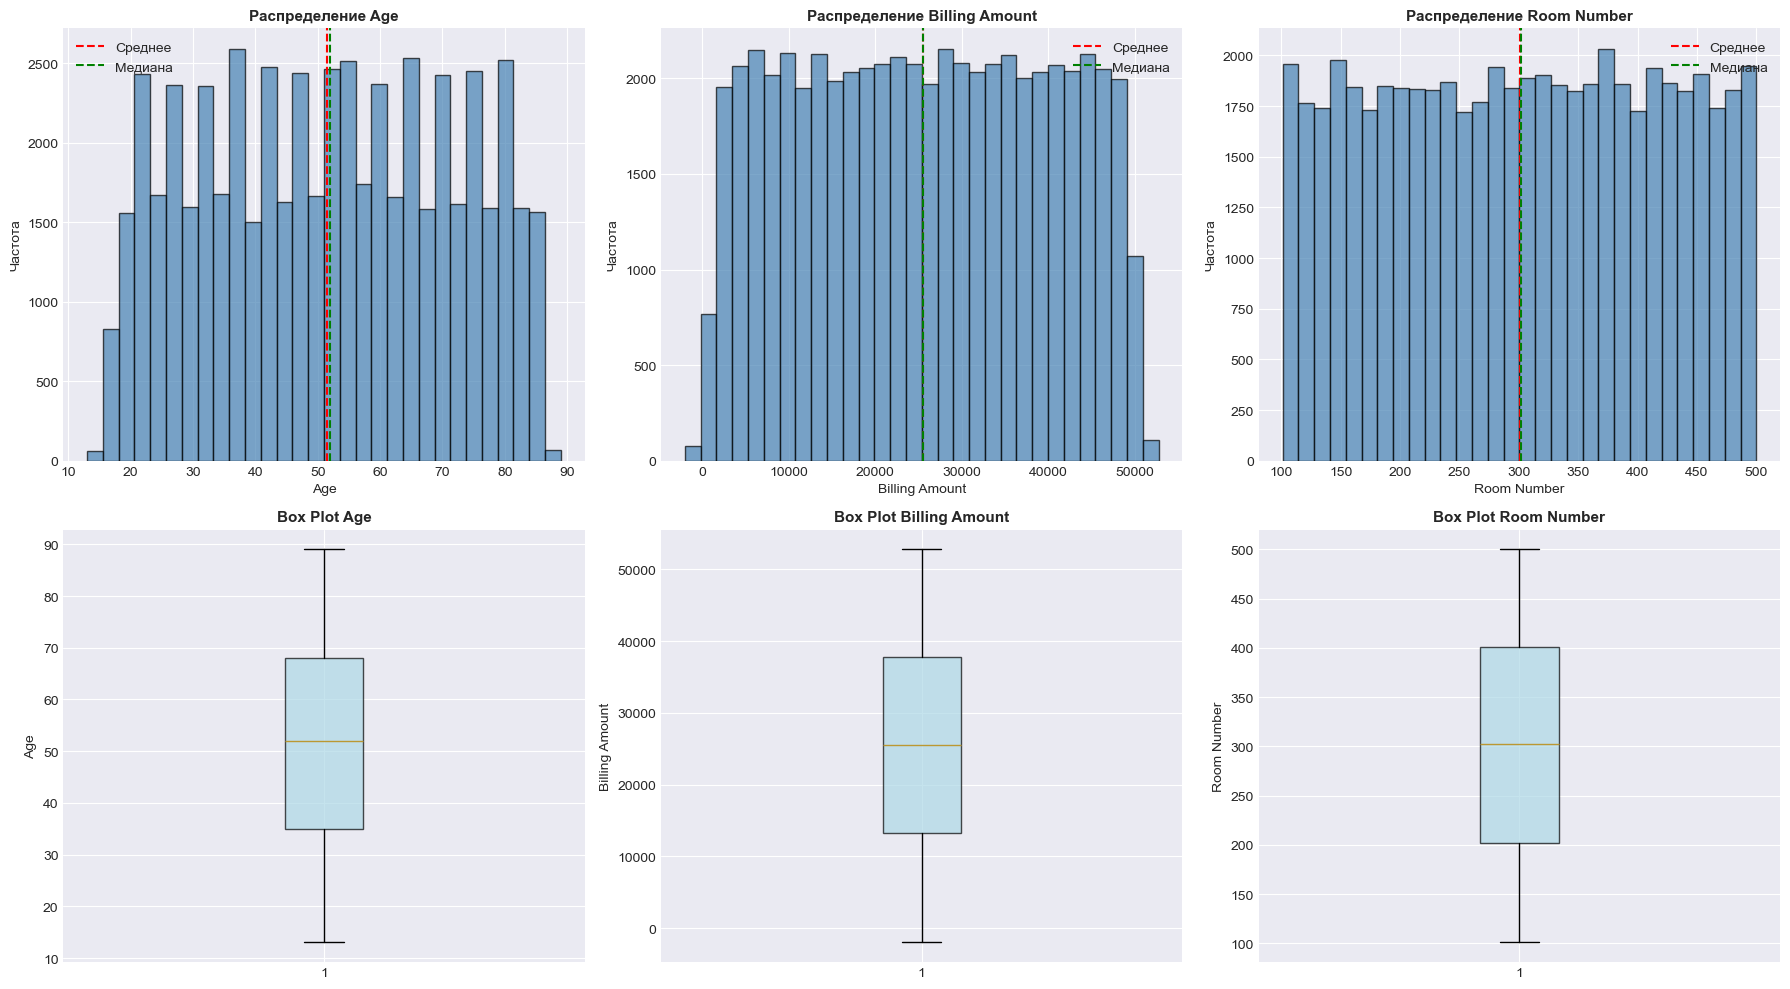


Описательная статистика:
                Age  Billing Amount   Room Number
count  55500.000000    55500.000000  55500.000000
mean      51.539459    25539.316097    301.134829
std       19.602454    14211.454431    115.243069
min       13.000000    -2008.492140    101.000000
25%       35.000000    13241.224652    202.000000
50%       52.000000    25538.069376    302.000000
75%       68.000000    37820.508436    401.000000
max       89.000000    52764.276736    500.000000


In [8]:
# Анализ числовых данных
print("="*60)
print("АНАЛИЗ ЧИСЛОВЫХ ДАННЫХ")
print("="*60)

numeric_cols = ['Age', 'Billing Amount', 'Room Number']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, col in enumerate(numeric_cols):
    # Гистограмма
    axes[0, idx].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, idx].axvline(df[col].mean(), color='red', linestyle='--', label='Среднее')
    axes[0, idx].axvline(df[col].median(), color='green', linestyle='--', label='Медиана')
    axes[0, idx].set_title(f'Распределение {col}', fontsize=11, fontweight='bold')
    axes[0, idx].set_xlabel(col)
    axes[0, idx].set_ylabel('Частота')
    axes[0, idx].legend()
    
    # Box plot
    axes[1, idx].boxplot(df[col], vert=True, patch_artist=True,
                         boxprops=dict(facecolor='lightblue', alpha=0.7))
    axes[1, idx].set_title(f'Box Plot {col}', fontsize=11, fontweight='bold')
    axes[1, idx].set_ylabel(col)

plt.tight_layout()
plt.show()

# Статистика
print("\nОписательная статистика:")
print(df[numeric_cols].describe())


АНАЛИЗ ПРИЗНАКА HOSPITAL

Уникальных больниц: 39876
Всего записей: 55500

ПРОБЛЕМЫ С НАЗВАНИЯМИ БОЛЬНИЦ:

1. Начинаются с 'and ': 5749
2. Заканчиваются запятой: 4776
3. Содержат ', and' или ' and' внутри: 15953
4. Заканчиваются на ' and': 5602

Примеры проблемных названий (первые 15):
1. Sons and Miller
2. Hernandez Rogers and Vang,
3. Powell Robinson and Valdez,
4. Sons Rich and
5. Powers Miller, and Flores
6. Torres, and Harrison Jones
7. and Sons Smith
8. Brown, and Jones Weaver
9. Sons and Cox
10. and Garcia Morris Cunningham,
11. and Howell Brooks, Rogers
12. and Mcclure White Boone,
13. Gates Brown, and Stuart
14. Knight and Nguyen, Riggs
15. Fernandez and Phillips, Singh


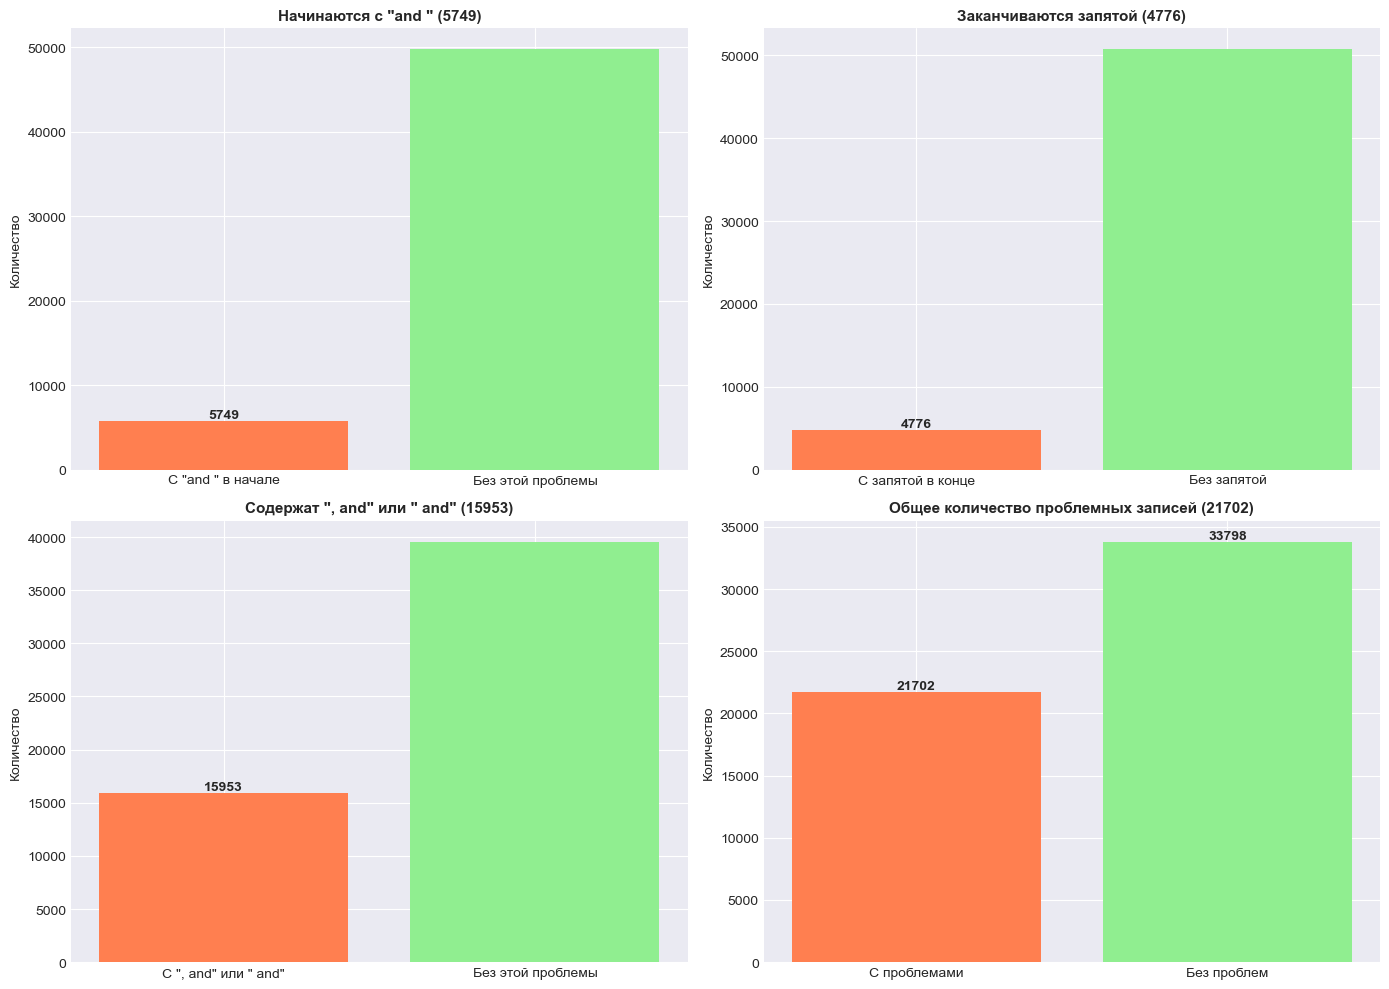


ТОП-20 БОЛЬНИЦ ПО КОЛИЧЕСТВУ ЗАПИСЕЙ:
Hospital
LLC Smith        44
Ltd Smith        39
Johnson PLC      38
Smith Ltd        37
Smith PLC        36
Smith Group      36
Johnson Inc      35
Smith Inc        34
Group Smith      32
Smith LLC        32
PLC Williams     30
LLC Johnson      30
PLC Smith        29
Brown Inc        28
Inc Brown        28
Johnson Group    27
Inc Smith        27
Inc Johnson      26
Group Johnson    26
Williams LLC     25
Name: count, dtype: int64


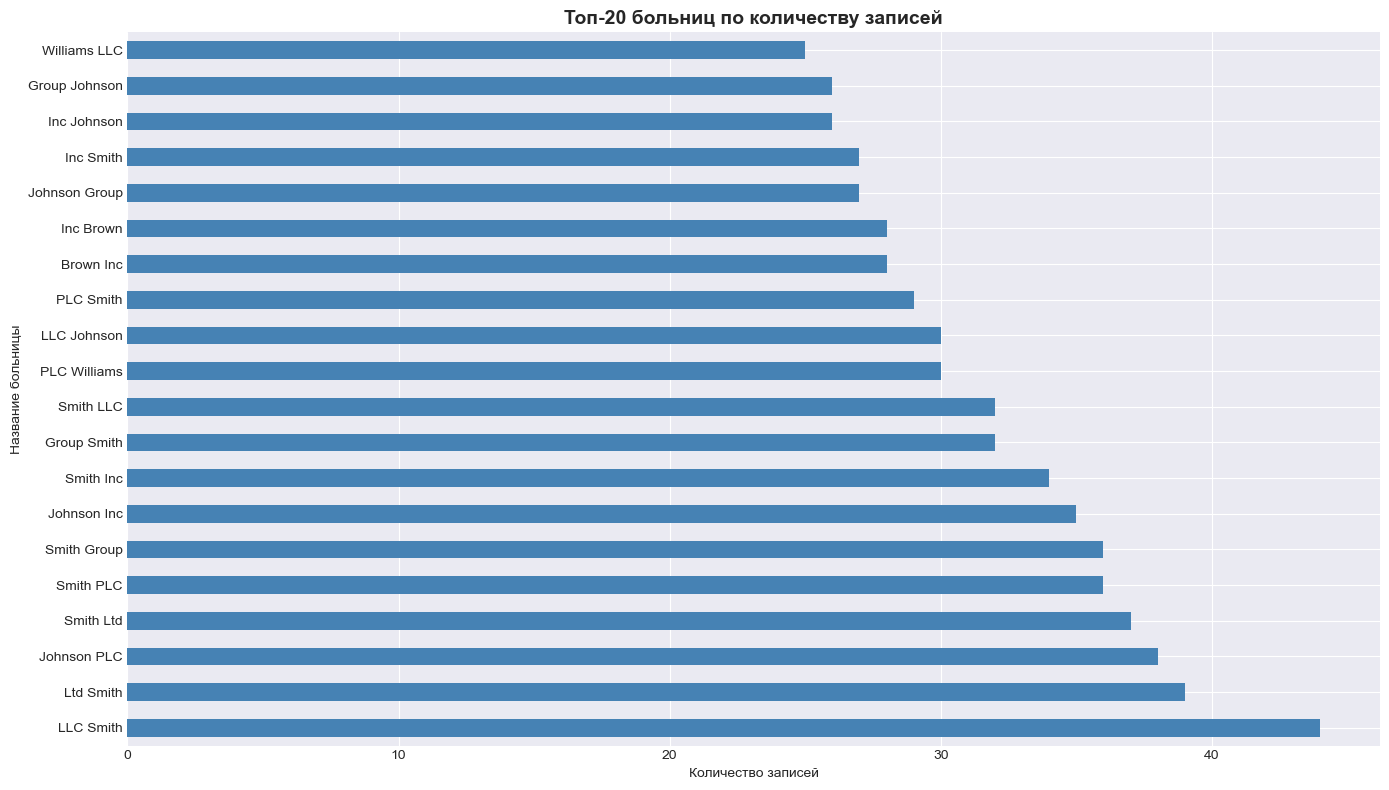

In [9]:
# Анализ признака Hospital
print("="*60)
print("АНАЛИЗ ПРИЗНАКА HOSPITAL")
print("="*60)

print(f"\nУникальных больниц: {df['Hospital'].nunique()}")
print(f"Всего записей: {len(df)}")

# Проблемы с названиями больниц
print("\nПРОБЛЕМЫ С НАЗВАНИЯМИ БОЛЬНИЦ:")

# 1. Начинаются с "and "
starts_with_and = df['Hospital'].str.startswith('and ', na=False)
and_count = starts_with_and.sum()
print(f"\n1. Начинаются с 'and ': {and_count}")

# 2. Заканчиваются запятой
ends_with_comma = df['Hospital'].str.endswith(',', na=False)
comma_count = ends_with_comma.sum()
print(f"2. Заканчиваются запятой: {comma_count}")

# 3. Содержат ", and" или " and" внутри
contains_and = df['Hospital'].str.contains(', and| and', na=False, regex=True)
and_in_middle_count = (contains_and & ~starts_with_and).sum()
print(f"3. Содержат ', and' или ' and' внутри: {and_in_middle_count}")

# 4. Заканчиваются на " and"
ends_with_and = df['Hospital'].str.endswith(' and', na=False)
ends_and_count = ends_with_and.sum()
print(f"4. Заканчиваются на ' and': {ends_and_count}")

# Примеры проблемных названий
problem_mask = starts_with_and | ends_with_comma | contains_and | ends_with_and
problem_hospitals = df[problem_mask]['Hospital'].unique()

print(f"\nПримеры проблемных названий (первые 15):")
for i, hosp in enumerate(problem_hospitals[:15], 1):
    print(f"{i}. {hosp}")

# Визуализация проблем
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Проблема 1: Начинаются с "and "
if and_count > 0:
    axes[0, 0].bar(['С "and " в начале', 'Без этой проблемы'], 
                  [and_count, len(df) - and_count],
                  color=['coral', 'lightgreen'])
    axes[0, 0].set_title(f'Начинаются с "and " ({and_count})', fontsize=11, fontweight='bold')
    axes[0, 0].set_ylabel('Количество')
    axes[0, 0].text(0, and_count, str(and_count), ha='center', va='bottom', fontweight='bold')
else:
    axes[0, 0].text(0.5, 0.5, 'Нет проблем', ha='center', va='center', fontsize=12)
    axes[0, 0].axis('off')

# Проблема 2: Заканчиваются запятой
if comma_count > 0:
    axes[0, 1].bar(['С запятой в конце', 'Без запятой'], 
                  [comma_count, len(df) - comma_count],
                  color=['coral', 'lightgreen'])
    axes[0, 1].set_title(f'Заканчиваются запятой ({comma_count})', fontsize=11, fontweight='bold')
    axes[0, 1].set_ylabel('Количество')
    axes[0, 1].text(0, comma_count, str(comma_count), ha='center', va='bottom', fontweight='bold')
else:
    axes[0, 1].text(0.5, 0.5, 'Нет проблем', ha='center', va='center', fontsize=12)
    axes[0, 1].axis('off')

# Проблема 3: Содержат ", and" или " and"
if and_in_middle_count > 0:
    axes[1, 0].bar(['С ", and" или " and"', 'Без этой проблемы'], 
                  [and_in_middle_count, len(df) - and_in_middle_count],
                  color=['coral', 'lightgreen'])
    axes[1, 0].set_title(f'Содержат ", and" или " and" ({and_in_middle_count})', fontsize=11, fontweight='bold')
    axes[1, 0].set_ylabel('Количество')
    axes[1, 0].text(0, and_in_middle_count, str(and_in_middle_count), ha='center', va='bottom', fontweight='bold')
else:
    axes[1, 0].text(0.5, 0.5, 'Нет проблем', ha='center', va='center', fontsize=12)
    axes[1, 0].axis('off')

# Общая статистика проблем
total_problems = problem_mask.sum()
axes[1, 1].bar(['С проблемами', 'Без проблем'], 
              [total_problems, len(df) - total_problems],
              color=['coral', 'lightgreen'])
axes[1, 1].set_title(f'Общее количество проблемных записей ({total_problems})', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Количество')
axes[1, 1].text(0, total_problems, str(total_problems), ha='center', va='bottom', fontweight='bold')
axes[1, 1].text(1, len(df) - total_problems, str(len(df) - total_problems), 
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Топ-20 больниц
print("\n" + "="*60)
print("ТОП-20 БОЛЬНИЦ ПО КОЛИЧЕСТВУ ЗАПИСЕЙ:")
print("="*60)
top_hospitals = df['Hospital'].value_counts().head(20)
print(top_hospitals)

# Визуализация топ-20
fig, ax = plt.subplots(figsize=(14, 8))
top_hospitals.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Топ-20 больниц по количеству записей', fontsize=14, fontweight='bold')
ax.set_xlabel('Количество записей')
ax.set_ylabel('Название больницы')
plt.tight_layout()
plt.show()


### Анализ дубликатов


АНАЛИЗ ДУБЛИКАТОВ
Полных дубликатов: 534

Примеры дублирующихся записей:

Пример 1 - Дубликат встречается 2 раз(а):
------------------------------------------------------------
Имя: Nancy glOVeR
Возраст: 58, Пол: Male
Группа крови: A-, Условие: Hypertension
Больница: Khan, and Rodriguez Fischer
Доктор: Jennifer Larson
Дата поступления: 2020-05-08
Дата выписки: 2020-06-01
Сумма: 19183.17
Палата: 378
Тип поступления: Emergency
Лекарство: Aspirin, Результаты: Abnormal
Страховка: Medicare

(Всего таких записей в датасете: 2)
------------------------------------------------------------

Пример 2 - Дубликат встречается 2 раз(а):
------------------------------------------------------------
Имя: DAVid higgInS
Возраст: 49, Пол: Female
Группа крови: B-, Условие: Arthritis
Больница: Evans and Hall Schneider,
Доктор: Erin Henderson MD
Дата поступления: 2021-03-05
Дата выписки: 2021-03-20
Сумма: 24948.48
Палата: 361
Тип поступления: Emergency
Лекарство: Penicillin, Результаты: Abnormal
Страховка: M

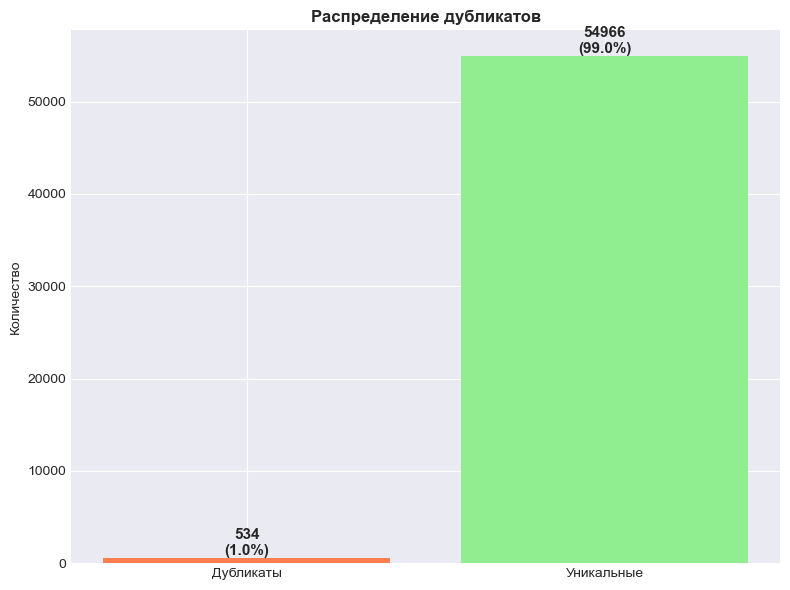


СТАТИСТИКА ДУБЛИКАТОВ:
Всего уникальных записей: 54966
Всего записей с дубликатами: 1068
Количество уникальных групп дубликатов: 534
Максимальное количество дублей одной записи: 2


In [10]:
# Анализ дубликатов
print("="*60)
print("АНАЛИЗ ДУБЛИКАТОВ")
print("="*60)

exact_duplicates = df.duplicated().sum()
print(f"Полных дубликатов: {exact_duplicates}")

if exact_duplicates > 0:
    # Находим все дубликаты (keep=False показывает все, включая первые)
    duplicate_mask = df.duplicated(keep=False)
    duplicate_indices = df[duplicate_mask].index.tolist()
    
    # Группируем дубликаты по всем значениям колонок
    duplicate_rows = df[duplicate_mask].copy()
    
    # Используем drop_duplicates(keep='first') для получения уникальных дубликатов
    # и затем находим все их копии
    unique_duplicates = df[duplicate_mask].drop_duplicates(keep='first')
    
    print(f"\nПримеры дублирующихся записей:")
    print("="*60)
    
    # Показываем первые несколько примеров
    max_examples_to_show = 5
    shown = 0
    
    for idx, (_, row) in enumerate(unique_duplicates.iterrows()):
        if shown >= max_examples_to_show:
            break
        
        # Находим все строки, идентичные этой
        matching_rows = df[df.eq(row.to_dict()).all(axis=1)]
        count = len(matching_rows)
        
        if count > 1:
            shown += 1
            print(f"\nПример {shown} - Дубликат встречается {count} раз(а):")
            print("-" * 60)
            print(f"Имя: {row['Name']}")
            print(f"Возраст: {row['Age']}, Пол: {row['Gender']}")
            print(f"Группа крови: {row['Blood Type']}, Условие: {row['Medical Condition']}")
            print(f"Больница: {row['Hospital']}")
            print(f"Доктор: {row['Doctor']}")
            print(f"Дата поступления: {row['Date of Admission']}")
            print(f"Дата выписки: {row['Discharge Date']}")
            print(f"Сумма: {row['Billing Amount']:.2f}")
            print(f"Палата: {row['Room Number']}")
            print(f"Тип поступления: {row['Admission Type']}")
            print(f"Лекарство: {row['Medication']}, Результаты: {row['Test Results']}")
            print(f"Страховка: {row['Insurance Provider']}")
            print(f"\n(Всего таких записей в датасете: {count})")
            print("-" * 60)
    
    # Подсчитываем количество уникальных групп дубликатов
    total_duplicate_groups = len(unique_duplicates)
    if shown < total_duplicate_groups:
        remaining = total_duplicate_groups - shown
        print(f"\n... и еще {remaining} групп дубликатов")
    
    # Визуализация
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.bar(['Дубликаты', 'Уникальные'], 
           [exact_duplicates, len(df) - exact_duplicates],
           color=['coral', 'lightgreen'])
    ax.set_title('Распределение дубликатов', fontsize=12, fontweight='bold')
    ax.set_ylabel('Количество')
    
    # Добавляем проценты
    total = len(df)
    pct_dup = (exact_duplicates / total) * 100
    pct_unique = ((total - exact_duplicates) / total) * 100
    ax.text(0, exact_duplicates, f'{exact_duplicates}\n({pct_dup:.1f}%)', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.text(1, total - exact_duplicates, f'{total - exact_duplicates}\n({pct_unique:.1f}%)', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Дополнительная статистика
    print("\n" + "="*60)
    print("СТАТИСТИКА ДУБЛИКАТОВ:")
    print("="*60)
    print(f"Всего уникальных записей: {len(df.drop_duplicates())}")
    print(f"Всего записей с дубликатами: {duplicate_mask.sum()}")
    print(f"Количество уникальных групп дубликатов: {total_duplicate_groups}")
    
    # Находим максимальное количество дублей
    max_duplicates = 0
    for _, row in unique_duplicates.iterrows():
        matching_rows = df[df.eq(row.to_dict()).all(axis=1)]
        count = len(matching_rows)
        if count > max_duplicates:
            max_duplicates = count
    print(f"Максимальное количество дублей одной записи: {max_duplicates}")
else:
    print("\nДубликатов не обнаружено!")
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.text(0.5, 0.5, 'Дубликатов не обнаружено!', 
            ha='center', va='center', fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.show()


## 3. Функции для очистки данных


In [11]:
def normalize_names(name):
    """Нормализация имени"""
    if pd.isna(name):
        return name
    
    # Удаляем префиксы и суффиксы
    prefixes_to_remove = ['Mr.', 'Mrs.', 'MS.', 'Dr.', 'mr.', 'mrs.', 'ms.', 'dr.', 'MR.', 'MRS.', 'DR.', 'DDs', 'dds', 'DDS']
    for prefix in prefixes_to_remove:
        name = re.sub(rf'^{re.escape(prefix)}\s+', '', name, flags=re.IGNORECASE)
        name = re.sub(rf'\s+{re.escape(prefix)}$', '', name, flags=re.IGNORECASE)
    
    # Убираем лишние пробелы
    name = ' '.join(name.split())
    
    # Приводим к Title Case
    name = name.title()
    
    return name

def fix_gender_by_name(df):
    """Исправление гендера на основе имени"""
    gender_fixes = {}
    
    common_female_names = ['emily', 'adrienne', 'christina', 'jasmine', 'nicole', 'katherine', 
                          'pamela', 'cassandra', 'mary', 'sarah', 'rebecca', 'samantha']
    common_male_names = ['bobby', 'christopher', 'robert', 'daniel', 'joshua', 'william', 
                        'james', 'thomas', 'paul', 'mark', 'marcus', 'hunter']
    
    for idx, row in df.iterrows():
        first_name = row['Name'].split()[0].lower() if pd.notna(row['Name']) else ''
        current_gender = row['Gender']
        
        if first_name in common_female_names and current_gender == 'Male':
            gender_fixes[idx] = 'Female'
        elif first_name in common_male_names and current_gender == 'Female':
            gender_fixes[idx] = 'Male'
    
    for idx, new_gender in gender_fixes.items():
        df.at[idx, 'Gender'] = new_gender
    
    return df, len(gender_fixes)

print("Функции для очистки данных определены!")


Функции для очистки данных определены!


## 4. Очистка данных с визуализацией


In [12]:
# Создаем копию для очистки
df_cleaned = df.copy()
original_size = len(df_cleaned)

print("="*60)
print("НАЧАЛО ОЧИСТКИ ДАННЫХ")
print("="*60)
print(f"Исходный размер: {original_size} строк\n")


НАЧАЛО ОЧИСТКИ ДАННЫХ
Исходный размер: 55500 строк



1. Нормализация имен...

Примеры имен ДО нормализации:
['Bobby JacksOn', 'LesLie TErRy', 'DaNnY sMitH', 'andrEw waTtS', 'adrIENNE bEll']

Примеры имен ПОСЛЕ нормализации:
['Bobby Jackson', 'Leslie Terry', 'Danny Smith', 'Andrew Watts', 'Adrienne Bell']
✓ Имена нормализованы!


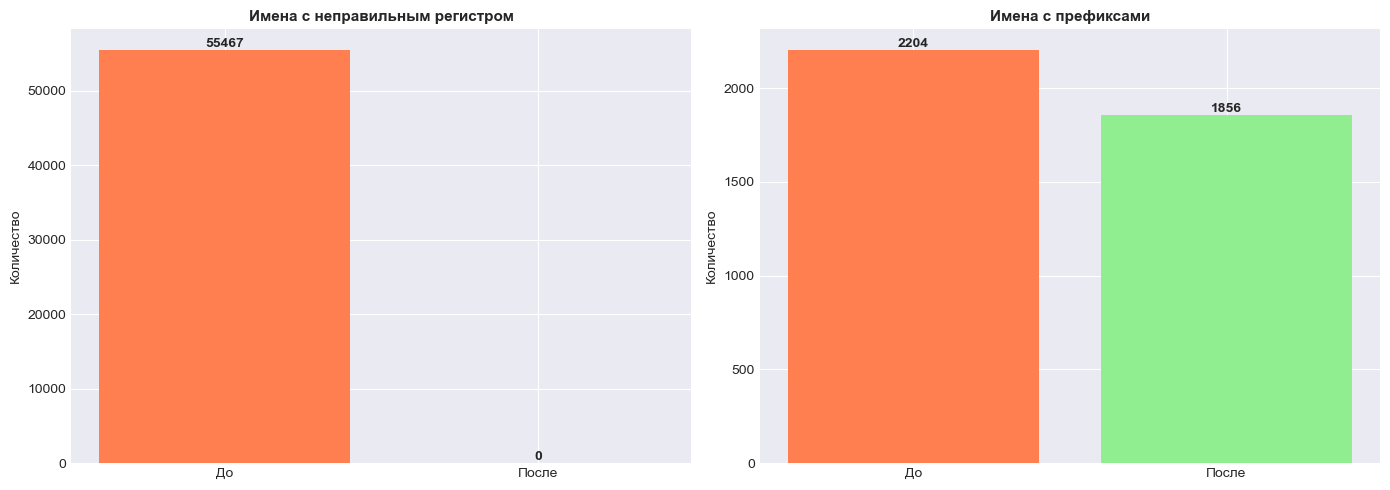

In [13]:
# 1. Нормализация имен
print("1. Нормализация имен...")

# Примеры до нормализации
print("\nПримеры имен ДО нормализации:")
print(df_cleaned['Name'].head(5).tolist())

# Нормализация
df_cleaned['Name'] = df_cleaned['Name'].apply(normalize_names)

# Примеры после нормализации
print("\nПримеры имен ПОСЛЕ нормализации:")
print(df_cleaned['Name'].head(5).tolist())

print("✓ Имена нормализованы!")

# Визуализация изменений
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Сравнение количества имен с проблемами до и после
wrong_before = df['Name'].apply(lambda x: x != x.title() and x.lower() != x.upper()).sum()
wrong_after = df_cleaned['Name'].apply(lambda x: x != x.title() and x.lower() != x.upper()).sum()

prefixes_list = ['Mr.', 'Mrs.', 'MS.', 'Dr.', 'mr.', 'mrs.', 'ms.', 'dr.', 'MR.', 'MRS.', 'DR.', 'DDs', 'dds', 'DDS']
prefix_before = df['Name'].str.contains('|'.join(prefixes_list), na=False).sum()
prefix_after = df_cleaned['Name'].str.contains('|'.join(prefixes_list), na=False).sum()

axes[0].bar(['До', 'После'], [wrong_before, wrong_after], color=['coral', 'lightgreen'])
axes[0].set_title('Имена с неправильным регистром', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Количество')
axes[0].text(0, wrong_before, str(wrong_before), ha='center', va='bottom', fontweight='bold')
axes[0].text(1, wrong_after, str(wrong_after), ha='center', va='bottom', fontweight='bold')

axes[1].bar(['До', 'После'], [prefix_before, prefix_after], color=['coral', 'lightgreen'])
axes[1].set_title('Имена с префиксами', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Количество')
axes[1].text(0, prefix_before, str(prefix_before), ha='center', va='bottom', fontweight='bold')
axes[1].text(1, prefix_after, str(prefix_after), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()



2. Исправление гендера...
✓ Исправлено несоответствий: 3818


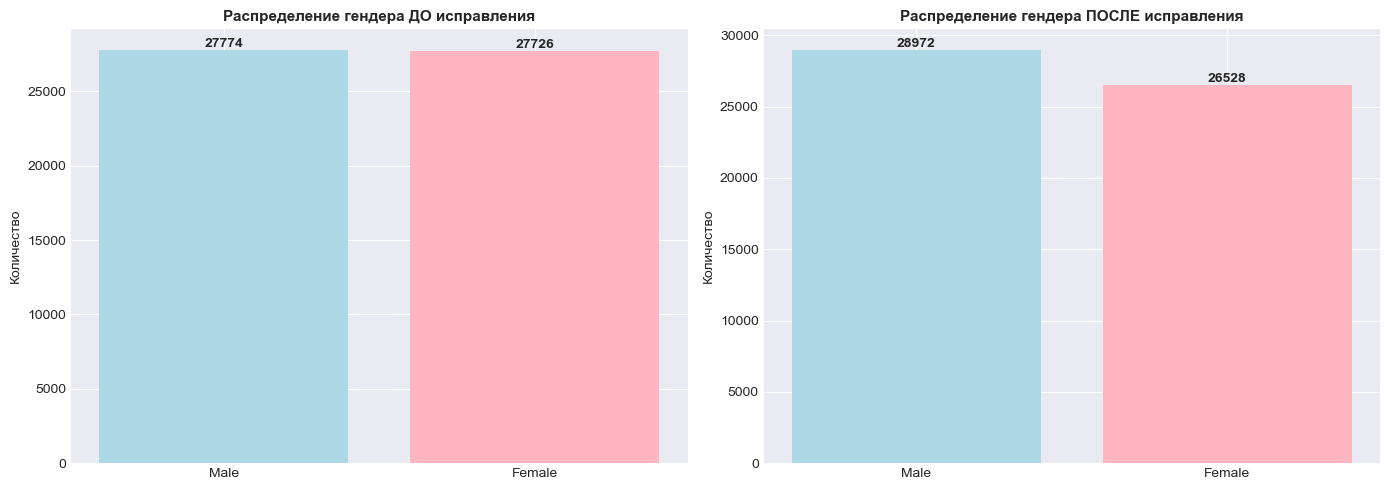

In [14]:
# 2. Исправление гендера
print("\n2. Исправление гендера...")

gender_before = df_cleaned['Gender'].value_counts()
df_cleaned, gender_fixes_count = fix_gender_by_name(df_cleaned)
gender_after = df_cleaned['Gender'].value_counts()

print(f"✓ Исправлено несоответствий: {gender_fixes_count}")

# Визуализация изменений гендера
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(gender_before.index, gender_before.values, color=['lightblue', 'lightpink'])
axes[0].set_title('Распределение гендера ДО исправления', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Количество')
for i, v in enumerate(gender_before.values):
    axes[0].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

axes[1].bar(gender_after.index, gender_after.values, color=['lightblue', 'lightpink'])
axes[1].set_title('Распределение гендера ПОСЛЕ исправления', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Количество')
for i, v in enumerate(gender_after.values):
    axes[1].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()



3. Очистка Billing Amount...
✓ Заменено отрицательных сумм: 108
✓ Суммы округлены до 2 знаков


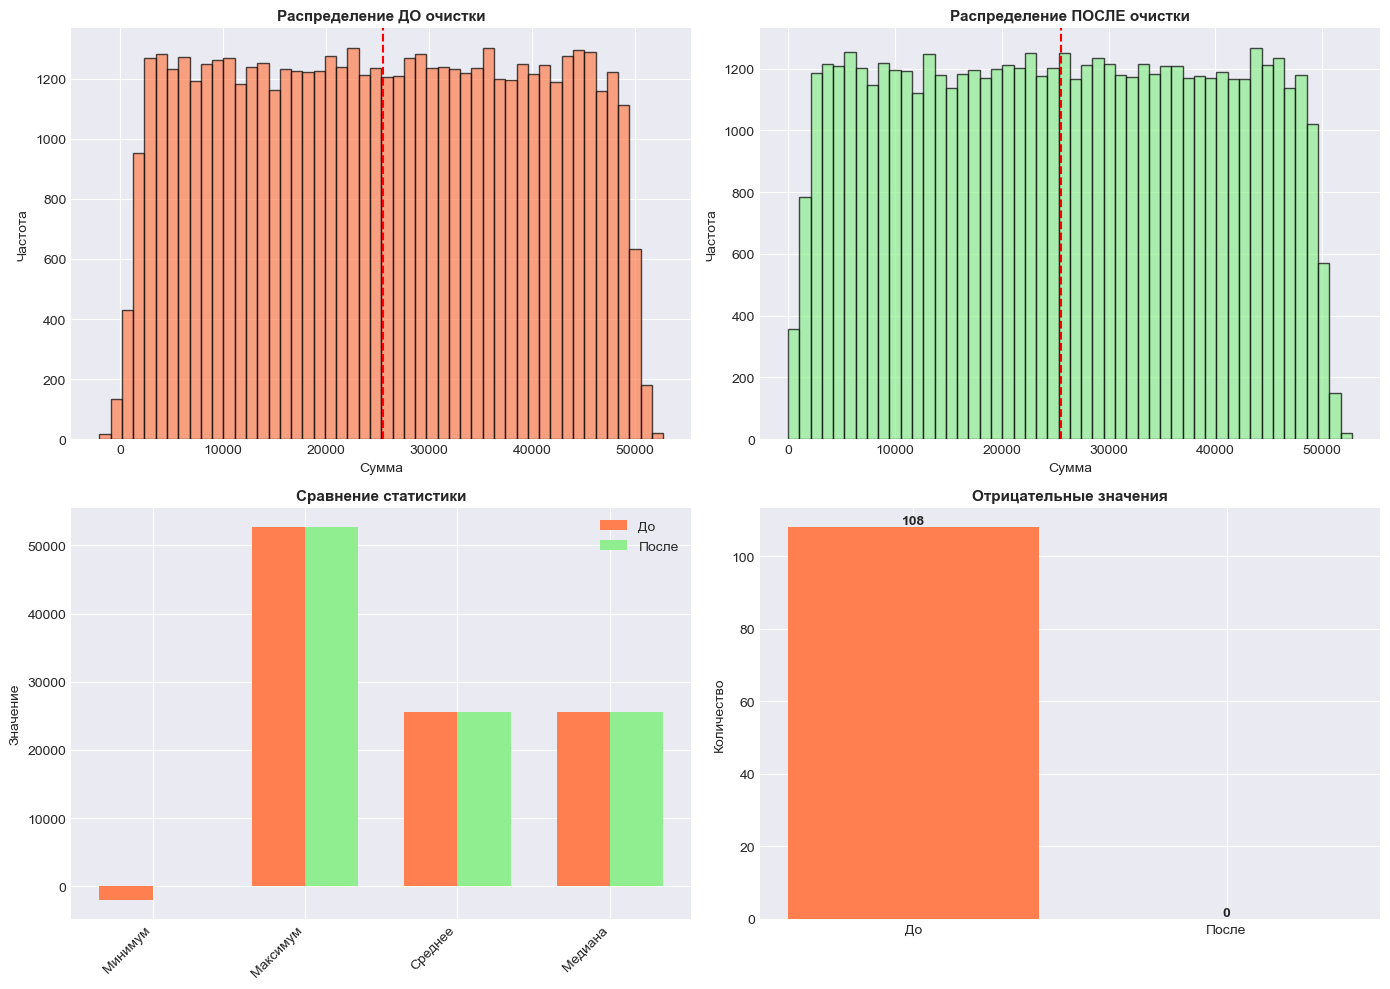


Статистика:
                    До         После
Минимум   -2008.492140      9.240000
Максимум  52764.276736  52764.280000
Среднее   25539.316097  25590.052956
Медиана   25538.069376  25573.820000


In [15]:
# 3. Очистка Billing Amount
print("\n3. Очистка Billing Amount...")

negative_count = (df_cleaned['Billing Amount'] < 0).sum()
if negative_count > 0:
    median_amount = df_cleaned[df_cleaned['Billing Amount'] > 0]['Billing Amount'].median()
    df_cleaned.loc[df_cleaned['Billing Amount'] < 0, 'Billing Amount'] = median_amount
    print(f"✓ Заменено отрицательных сумм: {negative_count}")

df_cleaned['Billing Amount'] = df_cleaned['Billing Amount'].round(2)
print("✓ Суммы округлены до 2 знаков")

# Визуализация изменений
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# До очистки
axes[0, 0].hist(df['Billing Amount'], bins=50, color='coral', alpha=0.7, edgecolor='black', label='До')
axes[0, 0].set_title('Распределение ДО очистки', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Сумма')
axes[0, 0].set_ylabel('Частота')
axes[0, 0].axvline(df['Billing Amount'].median(), color='red', linestyle='--', label='Медиана')

# После очистки
axes[0, 1].hist(df_cleaned['Billing Amount'], bins=50, color='lightgreen', alpha=0.7, edgecolor='black', label='После')
axes[0, 1].set_title('Распределение ПОСЛЕ очистки', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Сумма')
axes[0, 1].set_ylabel('Частота')
axes[0, 1].axvline(df_cleaned['Billing Amount'].median(), color='red', linestyle='--', label='Медиана')

# Сравнение статистики
stats_comparison = pd.DataFrame({
    'До': [df['Billing Amount'].min(), df['Billing Amount'].max(), 
           df['Billing Amount'].mean(), df['Billing Amount'].median()],
    'После': [df_cleaned['Billing Amount'].min(), df_cleaned['Billing Amount'].max(), 
              df_cleaned['Billing Amount'].mean(), df_cleaned['Billing Amount'].median()]
}, index=['Минимум', 'Максимум', 'Среднее', 'Медиана'])

x = np.arange(len(stats_comparison.index))
width = 0.35
axes[1, 0].bar(x - width/2, stats_comparison['До'], width, label='До', color='coral')
axes[1, 0].bar(x + width/2, stats_comparison['После'], width, label='После', color='lightgreen')
axes[1, 0].set_title('Сравнение статистики', fontsize=11, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(stats_comparison.index, rotation=45, ha='right')
axes[1, 0].set_ylabel('Значение')
axes[1, 0].legend()

# Отрицательные значения
negative_before = (df['Billing Amount'] < 0).sum()
negative_after = (df_cleaned['Billing Amount'] < 0).sum()
axes[1, 1].bar(['До', 'После'], [negative_before, negative_after], color=['coral', 'lightgreen'])
axes[1, 1].set_title('Отрицательные значения', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Количество')
axes[1, 1].text(0, negative_before, str(negative_before), ha='center', va='bottom', fontweight='bold')
axes[1, 1].text(1, negative_after, str(negative_after), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nСтатистика:")
print(stats_comparison)



4. Обработка дат...
✓ Даты обработаны


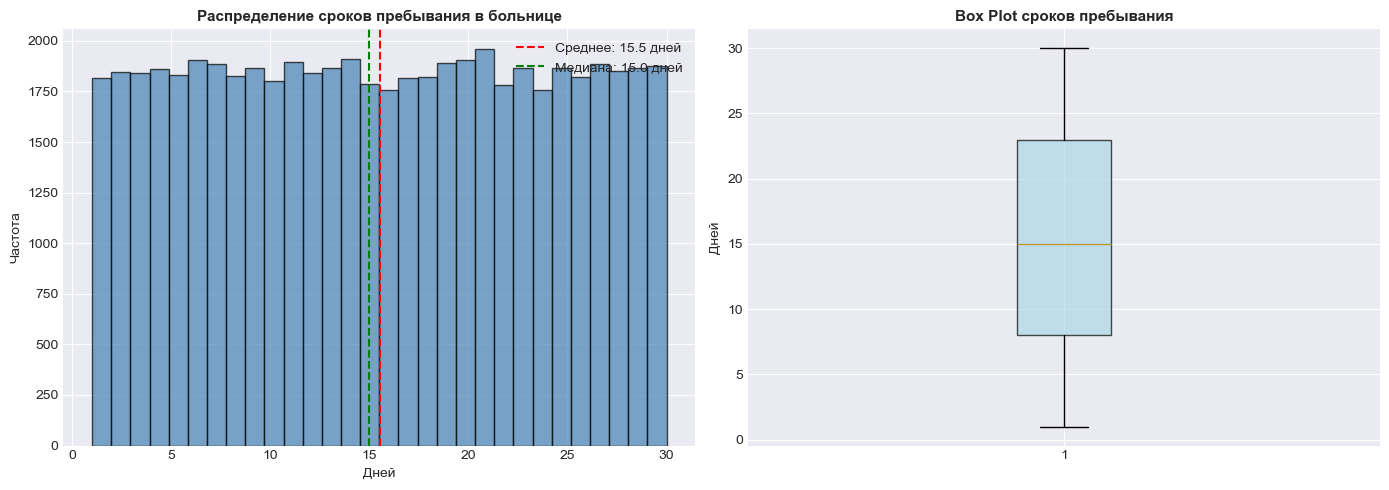


Статистика сроков пребывания:
count    55500.000000
mean        15.509009
std          8.659600
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Days_in_Hospital, dtype: float64


In [16]:
# 4. Проверка и обработка дат
print("\n4. Обработка дат...")

df_cleaned['Date of Admission'] = pd.to_datetime(df_cleaned['Date of Admission'], errors='coerce')
df_cleaned['Discharge Date'] = pd.to_datetime(df_cleaned['Discharge Date'], errors='coerce')

invalid_date_order = df_cleaned['Discharge Date'] < df_cleaned['Date of Admission']
invalid_count = invalid_date_order.sum()
if invalid_count > 0:
    df_cleaned.loc[invalid_date_order, 'Discharge Date'] = df_cleaned.loc[invalid_date_order, 'Date of Admission'] + pd.Timedelta(days=1)
    print(f"✓ Исправлено невалидных порядков дат: {invalid_count}")

invalid_dates = df_cleaned['Date of Admission'].isnull() | df_cleaned['Discharge Date'].isnull()
invalid_dates_count = invalid_dates.sum()
if invalid_dates_count > 0:
    df_cleaned = df_cleaned[~invalid_dates].copy()
    print(f"✓ Удалено строк с невалидными датами: {invalid_dates_count}")

# Вычисляем количество дней пребывания
df_cleaned['Days_in_Hospital'] = (df_cleaned['Discharge Date'] - df_cleaned['Date of Admission']).dt.days

print("✓ Даты обработаны")

# Визуализация сроков пребывания
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_cleaned['Days_in_Hospital'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Распределение сроков пребывания в больнице', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Дней')
axes[0].set_ylabel('Частота')
axes[0].axvline(df_cleaned['Days_in_Hospital'].mean(), color='red', linestyle='--', 
                label=f'Среднее: {df_cleaned["Days_in_Hospital"].mean():.1f} дней')
axes[0].axvline(df_cleaned['Days_in_Hospital'].median(), color='green', linestyle='--', 
                label=f'Медиана: {df_cleaned["Days_in_Hospital"].median():.1f} дней')
axes[0].legend()

axes[1].boxplot(df_cleaned['Days_in_Hospital'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[1].set_title('Box Plot сроков пребывания', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Дней')

plt.tight_layout()
plt.show()

print(f"\nСтатистика сроков пребывания:")
print(df_cleaned['Days_in_Hospital'].describe())



5. Очистка названий больниц...

Примеры названий ДО очистки:
['Sons and Miller', 'Hernandez Rogers and Vang,', 'Powell Robinson and Valdez,', 'Sons Rich and', 'Powers Miller, and Flores', 'Torres, and Harrison Jones', 'and Sons Smith', 'Brown, and Jones Weaver', 'Sons and Cox', 'and Garcia Morris Cunningham,']

Примеры названий ПОСЛЕ очистки:
['Sons And Miller', 'Hernandez Rogers And Vang', 'Powell Robinson And Valdez', 'Sons Rich', 'Powers Miller Flores', 'Torres Harrison Jones', 'Sons Smith', 'Brown Jones Weaver', 'Sons And Cox', 'Garcia Morris Cunningham']

✓ Исправлено:
  - Начинались с 'and ': 5749 → 0
  - Заканчивались запятой: 4776 → 0
  - Содержали ', and' или ' and': 15953 → 0
  - Заканчивались на ' and': 5602 → 0


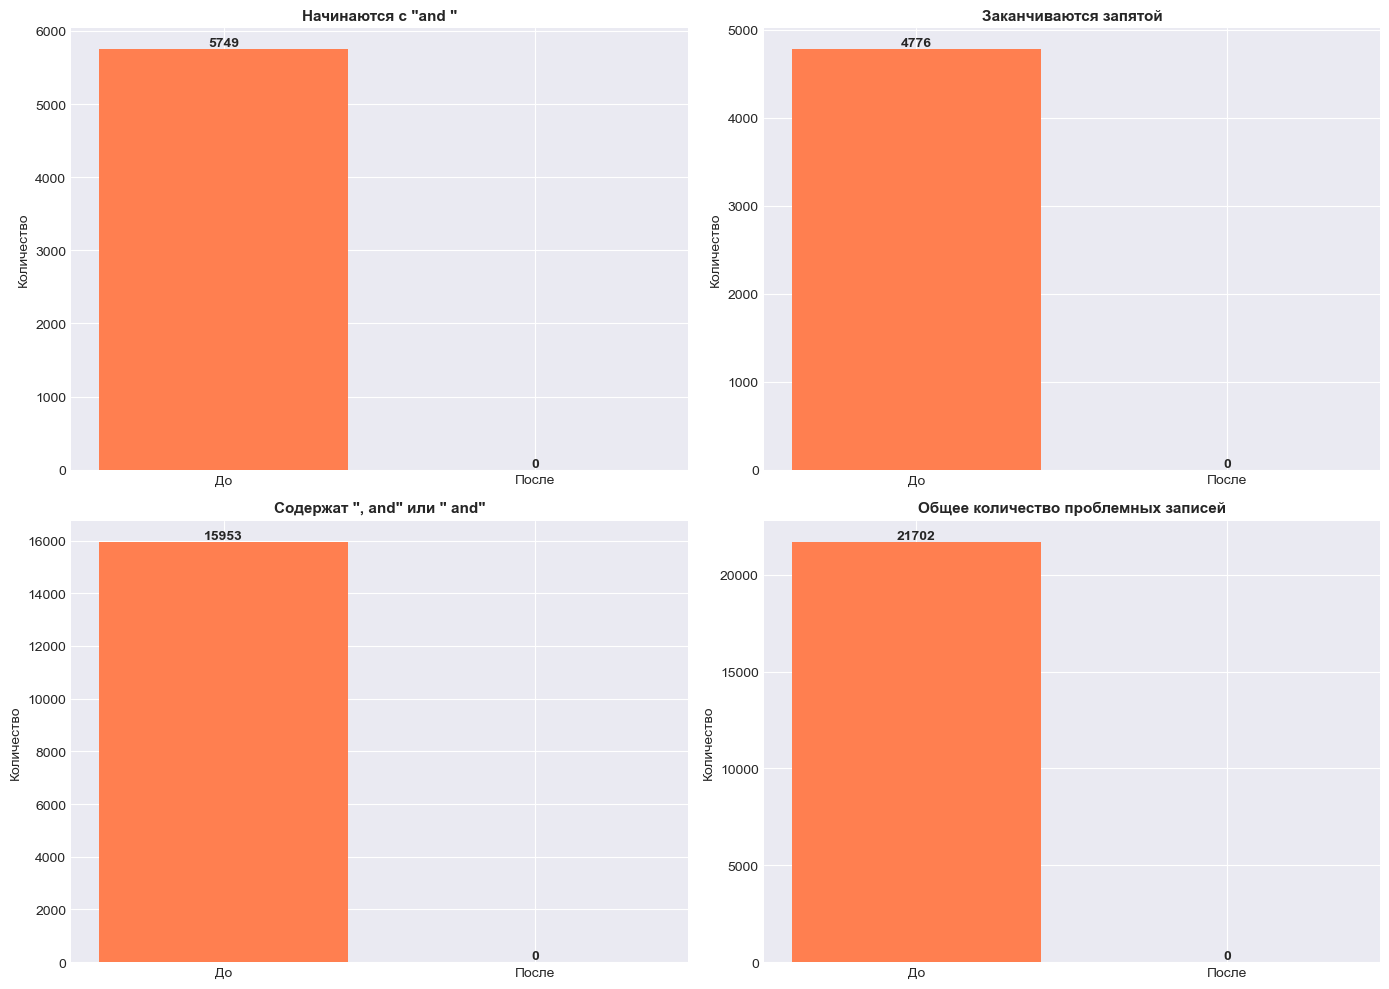


Уникальных больниц: 39876 → 39635

6. Проверка и форматирование дат...
Тип Date of Admission: datetime64[ns]
Тип Discharge Date: datetime64[ns]
✓ Date of Admission преобразована в строковый формат
✓ Discharge Date преобразована в строковый формат
✓ Удалены вспомогательные колонки: ['Days_in_Hospital']

✓ Очистка данных завершена!
Финальный размер датасета: (55500, 15)


In [17]:

def clean_hospital_name(name):
    """
    Очищает название больницы от лишних слов и знаков препинания
    """
    if pd.isna(name):
        return name
    
    name = str(name).strip()
    
    # Удаляем лишние пробелы
    name = re.sub(r'\s+', ' ', name)
    
    # Удаляем начинающиеся с "and "
    name = re.sub(r'^and\s+', '', name, flags=re.IGNORECASE)
    
    # Удаляем заканчивающиеся на " and"
    name = re.sub(r'\s+and$', '', name, flags=re.IGNORECASE)
    
    # Удаляем заканчивающиеся на запятую
    name = re.sub(r',$', '', name)
    
    # Удаляем ", and" в середине
    name = re.sub(r',\s*and\s+', ' ', name, flags=re.IGNORECASE)
    
    # Удаляем лишние пробелы после очистки
    name = re.sub(r'\s+', ' ', name).strip()
    
    # Приводим к правильному регистру (каждое слово с заглавной)
    name = name.title()
    
    return name

# 5. Очистка названий больниц
print("\n5. Очистка названий больниц...")

# Подсчитываем проблемы до очистки
starts_with_and_before = df_cleaned['Hospital'].str.startswith('and ', na=False).sum()
ends_with_comma_before = df_cleaned['Hospital'].str.endswith(',', na=False).sum()
contains_and_before = df_cleaned['Hospital'].str.contains(', and| and', na=False, regex=True).sum()
ends_with_and_before = df_cleaned['Hospital'].str.endswith(' and', na=False).sum()

# Примеры до очистки
print("\nПримеры названий ДО очистки:")
problem_before = df_cleaned['Hospital'].str.startswith('and ', na=False) | \
                 df_cleaned['Hospital'].str.endswith(',', na=False) | \
                 df_cleaned['Hospital'].str.contains(', and| and', na=False, regex=True) | \
                 df_cleaned['Hospital'].str.endswith(' and', na=False)
print(df_cleaned[problem_before]['Hospital'].head(10).tolist())

# Очистка
df_cleaned['Hospital'] = df_cleaned['Hospital'].apply(clean_hospital_name)

# Подсчитываем проблемы после очистки
starts_with_and_after = df_cleaned['Hospital'].str.startswith('and ', na=False).sum()
ends_with_comma_after = df_cleaned['Hospital'].str.endswith(',', na=False).sum()
contains_and_after = df_cleaned['Hospital'].str.contains(', and| and', na=False, regex=True).sum()
ends_with_and_after = df_cleaned['Hospital'].str.endswith(' and', na=False).sum()

# Примеры после очистки
print("\nПримеры названий ПОСЛЕ очистки:")
problem_after = df_cleaned['Hospital'].str.startswith('and ', na=False) | \
                df_cleaned['Hospital'].str.endswith(',', na=False) | \
                df_cleaned['Hospital'].str.contains(', and| and', na=False, regex=True) | \
                df_cleaned['Hospital'].str.endswith(' and', na=False)
cleaned_examples = df_cleaned[problem_before & ~problem_after]['Hospital'].head(10).tolist()
if cleaned_examples:
    print(cleaned_examples)
else:
    print("Все проблемы исправлены!")

print(f"\n✓ Исправлено:")
print(f"  - Начинались с 'and ': {starts_with_and_before} → {starts_with_and_after}")
print(f"  - Заканчивались запятой: {ends_with_comma_before} → {ends_with_comma_after}")
print(f"  - Содержали ', and' или ' and': {contains_and_before} → {contains_and_after}")
print(f"  - Заканчивались на ' and': {ends_with_and_before} → {ends_with_and_after}")

# Визуализация изменений
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Начинаются с "and "
axes[0, 0].bar(['До', 'После'], [starts_with_and_before, starts_with_and_after], 
              color=['coral', 'lightgreen'])
axes[0, 0].set_title('Начинаются с "and "', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Количество')
axes[0, 0].text(0, starts_with_and_before, str(starts_with_and_before), 
               ha='center', va='bottom', fontweight='bold')
axes[0, 0].text(1, starts_with_and_after, str(starts_with_and_after), 
               ha='center', va='bottom', fontweight='bold')

# Заканчиваются запятой
axes[0, 1].bar(['До', 'После'], [ends_with_comma_before, ends_with_comma_after], 
              color=['coral', 'lightgreen'])
axes[0, 1].set_title('Заканчиваются запятой', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Количество')
axes[0, 1].text(0, ends_with_comma_before, str(ends_with_comma_before), 
               ha='center', va='bottom', fontweight='bold')
axes[0, 1].text(1, ends_with_comma_after, str(ends_with_comma_after), 
               ha='center', va='bottom', fontweight='bold')

# Содержат ", and" или " and"
axes[1, 0].bar(['До', 'После'], [contains_and_before, contains_and_after], 
              color=['coral', 'lightgreen'])
axes[1, 0].set_title('Содержат ", and" или " and"', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Количество')
axes[1, 0].text(0, contains_and_before, str(contains_and_before), 
               ha='center', va='bottom', fontweight='bold')
axes[1, 0].text(1, contains_and_after, str(contains_and_after), 
               ha='center', va='bottom', fontweight='bold')

# Общая статистика
total_before = problem_before.sum()
total_after = problem_after.sum()
axes[1, 1].bar(['До', 'После'], [total_before, total_after], 
              color=['coral', 'lightgreen'])
axes[1, 1].set_title('Общее количество проблемных записей', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Количество')
axes[1, 1].text(0, total_before, str(total_before), 
               ha='center', va='bottom', fontweight='bold')
axes[1, 1].text(1, total_after, str(total_after), 
               ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Сравнение уникальных больниц до и после
unique_before = df['Hospital'].nunique()
unique_after = df_cleaned['Hospital'].nunique()
print(f"\nУникальных больниц: {unique_before} → {unique_after}")

# 6. Проверяем и преобразуем даты если нужно
print("\n6. Проверка и форматирование дат...")

# Проверяем тип данных колонок с датами
print(f"Тип Date of Admission: {df_cleaned['Date of Admission'].dtype}")
print(f"Тип Discharge Date: {df_cleaned['Discharge Date'].dtype}")

# Если даты уже в строковом формате, оставляем как есть
if df_cleaned['Date of Admission'].dtype == 'object':
    print("✓ Date of Admission уже в строковом формате")
else:
    # Преобразуем обратно в строки если это datetime
    df_cleaned['Date of Admission'] = df_cleaned['Date of Admission'].dt.strftime('%Y-%m-%d')
    print("✓ Date of Admission преобразована в строковый формат")

if df_cleaned['Discharge Date'].dtype == 'object':
    print("✓ Discharge Date уже в строковом формате")
else:
    # Преобразуем обратно в строки если это datetime
    df_cleaned['Discharge Date'] = df_cleaned['Discharge Date'].dt.strftime('%Y-%m-%d')
    print("✓ Discharge Date преобразована в строковый формат")

# Удаляем вспомогательные колонки если они существуют
columns_to_drop = ['Days_in_Hospital', 'Admission_Year', 'Admission_Month', 'Admission_DayOfWeek', 'Admission_Quarter']
existing_columns_to_drop = [col for col in columns_to_drop if col in df_cleaned.columns]

if existing_columns_to_drop:
    df_cleaned.drop(existing_columns_to_drop, axis=1, inplace=True)
    print(f"✓ Удалены вспомогательные колонки: {existing_columns_to_drop}")
else:
    print("✓ Вспомогательные колонки не найдены")

print("\n✓ Очистка данных завершена!")
print(f"Финальный размер датасета: {df_cleaned.shape}")



7. Удаление дубликатов...
✓ Удалено полных дубликатов: 534


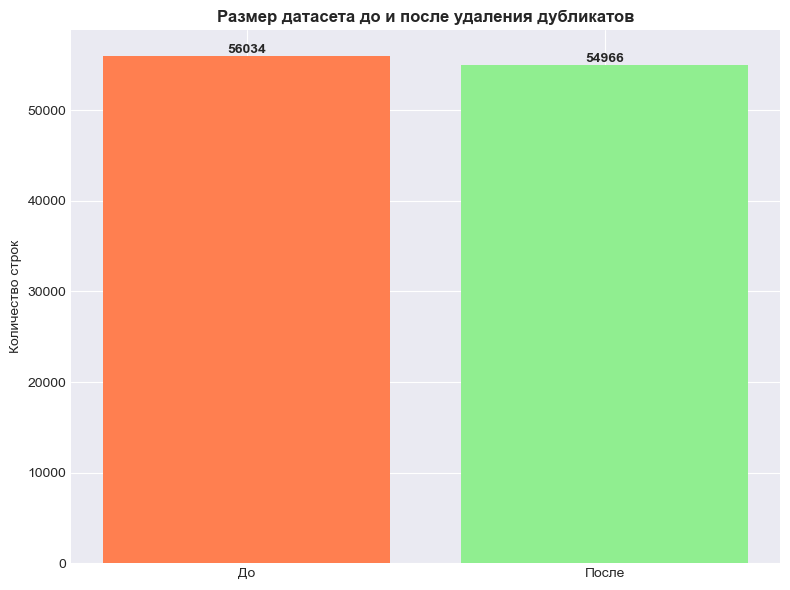

In [18]:
# 7. Удаление дубликатов
print("\n7. Удаление дубликатов...")

duplicates_before = df_cleaned.duplicated().sum()
if duplicates_before > 0:
    df_cleaned = df_cleaned.drop_duplicates().copy()
    print(f"✓ Удалено полных дубликатов: {duplicates_before}")

# Визуализация
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(['До', 'После'], 
       [len(df) + duplicates_before, len(df_cleaned)],
       color=['coral', 'lightgreen'])
ax.set_title('Размер датасета до и после удаления дубликатов', fontsize=12, fontweight='bold')
ax.set_ylabel('Количество строк')
ax.text(0, len(df) + duplicates_before, f'{len(df) + duplicates_before}', 
        ha='center', va='bottom', fontweight='bold')
ax.text(1, len(df_cleaned), f'{len(df_cleaned)}', 
        ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


In [20]:
# 6. Форматирование дат обратно в строки и удаление вспомогательных колонок
df_cleaned['Date of Admission'] = df_cleaned['Date of Admission'].dt.strftime('%Y-%m-%d')
df_cleaned['Discharge Date'] = df_cleaned['Discharge Date'].dt.strftime('%Y-%m-%d')

if 'Days_in_Hospital' in df_cleaned.columns:
    df_cleaned.drop('Days_in_Hospital', axis=1, inplace=True)

print("✓ Вспомогательные колонки удалены")


AttributeError: Can only use .dt accessor with datetimelike values

## 5. Итоговое сравнение и результаты


In [ ]:
# Итоговая статистика
final_size = len(df_cleaned)
removed = original_size - final_size

print("="*60)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ ОЧИСТКИ")
print("="*60)
print(f"Исходный размер: {original_size} строк")
print(f"Финальный размер: {final_size} строк")
print(f"Удалено строк: {removed} ({removed/original_size*100:.2f}%)")
print(f"Сохранено строк: {final_size} ({final_size/original_size*100:.2f}%)")
print("="*60)

# Визуализация изменений размера
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Изменение размера датасета
axes[0].bar(['Исходный', 'Финальный'], [original_size, final_size], 
            color=['coral', 'lightgreen'], width=0.5)
axes[0].set_title('Изменение размера датасета', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Количество строк')
axes[0].text(0, original_size, f'{original_size:,}', ha='center', va='bottom', fontweight='bold')
axes[0].text(1, final_size, f'{final_size:,}', ha='center', va='bottom', fontweight='bold')

# Круговая диаграмма сохраненных/удаленных
axes[1].pie([final_size, removed], labels=['Сохранено', 'Удалено'], 
            colors=['lightgreen', 'coral'], autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Распределение строк', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
# Сравнение категориальных данных до и после
categorical_cols = ['Gender', 'Blood Type', 'Medical Condition', 'Admission Type', 
                   'Medication', 'Test Results']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    before = df[col].value_counts()
    after = df_cleaned[col].value_counts()
    
    # Объединяем индексы для сравнения
    all_keys = sorted(set(before.index) | set(after.index))
    
    before_vals = [before.get(k, 0) for k in all_keys]
    after_vals = [after.get(k, 0) for k in all_keys]
    
    x = np.arange(len(all_keys))
    width = 0.35
    
    axes[idx].bar(x - width/2, before_vals, width, label='До', color='coral', alpha=0.7)
    axes[idx].bar(x + width/2, after_vals, width, label='После', color='lightgreen', alpha=0.7)
    axes[idx].set_title(col, fontsize=11, fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(all_keys, rotation=45, ha='right')
    axes[idx].set_ylabel('Количество')
    axes[idx].legend()

# Скрываем лишние подграфики
for idx in range(len(categorical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# Просмотр очищенного датасета
print("Первые 10 строк очищенного датасета:")
df_cleaned.head(10)


In [ ]:
# Сохранение очищенных данных
output_file = 'healthcare_dataset_cleaned.csv'
df_cleaned.to_csv(output_file, index=False)
print(f"✓ Очищенные данные сохранены в {output_file}")
print(f"✓ Размер сохраненного файла: {final_size} строк, {df_cleaned.shape[1]} колонок")


## Итоговые выводы

### Выполненные операции:
1. ✅ Нормализация имен (Title Case, удаление префиксов)
2. ✅ Исправление гендера (на основе имен)
3. ✅ Очистка Billing Amount (удаление отрицательных значений, округление)
4. ✅ Обработка дат (валидация, исправление порядка)
5. ✅ Удаление дубликатов
6. ✅ Проверка пропусков
7. ✅ Валидация возраста

### Результаты:
Все данные успешно подготовлены и готовы для дальнейшего анализа!

Финальные результаты отображаются в предыдущих ячейках.
